In [23]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("long.csv")

In [7]:
# Phân tích dữ liệu
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0


In [9]:
# Kiểm tra dữ liệu có bị thiếu hay không
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
Hour      0
dtype: int64

In [12]:
## vậy là dữ liệu không bị thiếu
## tiếp theo chúng ta kiểm tra loại dữ liệu để tiến hành trực quan hoá
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 32 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     28

In [ ]:
# Vậy là toàn bộ dữ liệu là dạng số ( không có string hoặc các kiểu dữ liệu dạng chữ)

In [14]:
# Trước khi trực quan hoá dữ liệu ta cần hiểu dữ liệu là gì trước
# Hiểu về các Đặc trưng (Features)

##Do yêu cầu bảo mật, các đặc trưng giao dịch gốc đã được biến đổi bằng **Phân tích Thành phần Chính (Principal Component Analysis - PCA)**:

##- **V1 đến V28**: 28 thành phần chính thu được từ phép biến đổi PCA. Các thành phần này nắm bắt được phương sai của các đặc trưng gốc nhưng **không thể diễn giải trực tiếp theo ý nghĩa kinh doanh**.

##- **Time**: Số giây trôi qua giữa giao dịch hiện tại và giao dịch đầu tiên trong tập dữ liệu. Rất hữu ích để phát hiện các mẫu hành vi theo thời gian.

##- **Amount**: Số tiền giao dịch (đơn vị: euro). Đây là đặc trưng quan trọng cho các mô hình học nhạy cảm với chi phí (cost-sensitive learning) và là một chỉ báo chính trong bài toán phát hiện gian lận.

##- **Class**: Biến mục tiêu (response variable)
  ##- 0 = Giao dịch hợp pháp (Legitimate)
  ##- 1 = Giao dịch gian lận (Fraudulent)

##**Lưu ý quan trọng**:

##Mặc dù các đặc trưng PCA (V1-V28) không thể diễn giải trực tiếp bởi con người, chúng vẫn chứa rất nhiều thông tin giá trị về các mẫu giao dịch. Phân tích **SHAP** sẽ giúp chúng ta hiểu được thành phần nào trong số đó quan trọng nhất đối với việc phát hiện gian lận.

In [27]:
# Tính toán để trực quan hoá
fraud_count = df['Class'].value_counts()
fraud_percentage = df['Class'].value_counts(normalize=True) * 100

/var/folders/q2/rf1fqv4x35d9zrv8kmtb11ph0000gn/T/ipykernel_23426/3387704212.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', ax=axes[0], palette=['#2ecc71', '#e74c3c'])


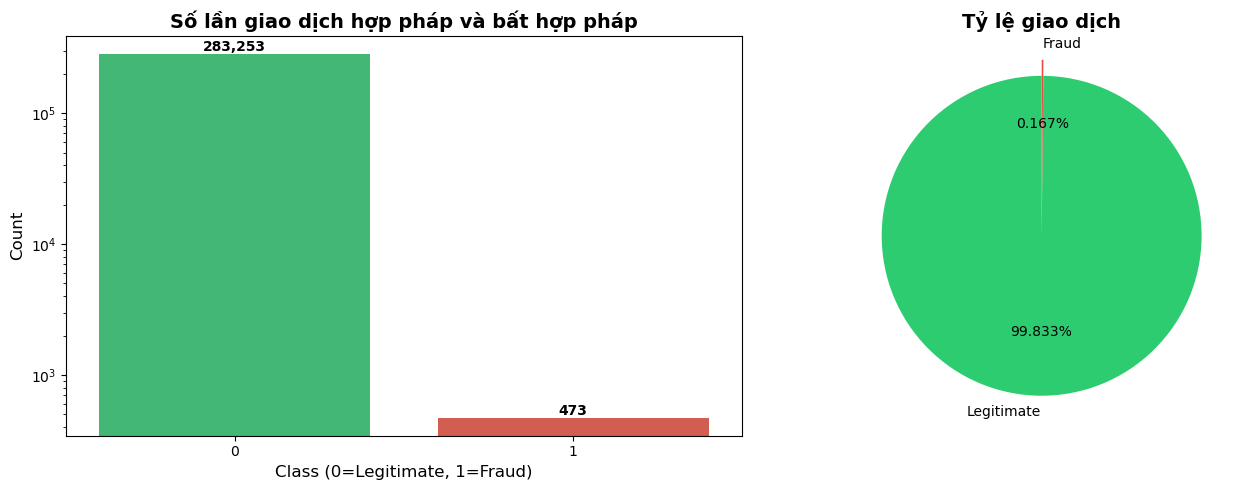

In [35]:
# Trực quan hoá dữ liệu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Count plot
sns.countplot(data=df, x='Class', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Số lần giao dịch hợp pháp và bất hợp pháp', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class (0=Legitimate, 1=Fraud)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_yscale('log')
for i, v in enumerate(fraud_count):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Percentage plot
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(fraud_count, labels=['Legitimate', 'Fraud'], autopct='%1.3f%%', 
            colors=colors, startangle=90, explode=[0, 0.1])
axes[1].set_title('Tỷ lệ giao dịch', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
## Vậy là chúng ta có khoảng 473 giao dịch bất hợp pháp trên tổng số giao dịch
## Tỷ lệ chiếm khoảng 0,167%


/var/folders/q2/rf1fqv4x35d9zrv8kmtb11ph0000gn/T/ipykernel_23426/1611771220.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x='Class', y='Amount', ax=axes[0], palette=['#2ecc71', '#e74c3c'])


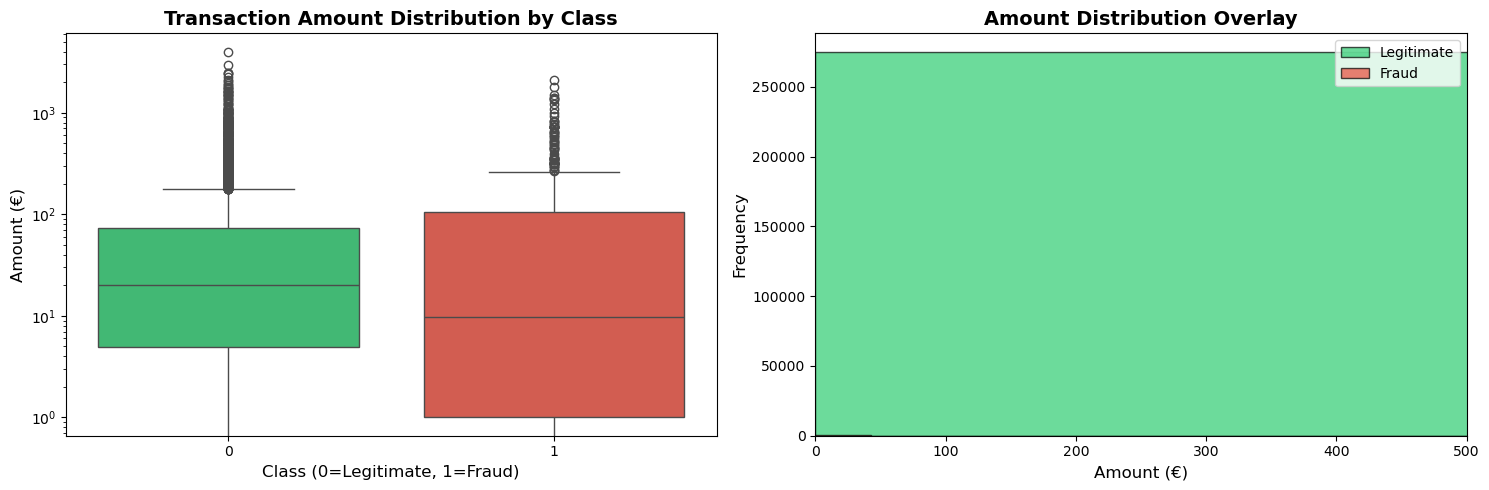

 số lượng giao dịch bất hợp pháp ít, những vẫn tồn tại những giao dịch với số tiền lớn


In [34]:
## Số lượng giao dịch theo class
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
df_sample = df[df['Class'] == 1].copy()  # All frauds
df_sample = pd.concat([df_sample, df[df['Class'] == 0].sample(n=5000) ]) # Sample legitimate

sns.boxplot(data=df_sample, x='Class', y='Amount', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Transaction Amount Distribution by Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class (0=Legitimate, 1=Fraud)', fontsize=12)
axes[0].set_ylabel('Amount (€)', fontsize=12)
axes[0].set_yscale('log')

# Histogram
axes[1].hist(df[df['Class'] == 0]['Amount'], bins=50, alpha=0.7, label='Legitimate', color='#2ecc71', edgecolor='black')
axes[1].hist(df[df['Class'] == 1]['Amount'], bins=50, alpha=0.7, label='Fraud', color='#e74c3c', edgecolor='black')
axes[1].set_title('Amount Distribution Overlay', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Amount (€)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()
axes[1].set_xlim([0, 500])

plt.tight_layout()
plt.show()
print(" số lượng giao dịch bất hợp pháp ít, những vẫn tồn tại những giao dịch với số tiền lớn")

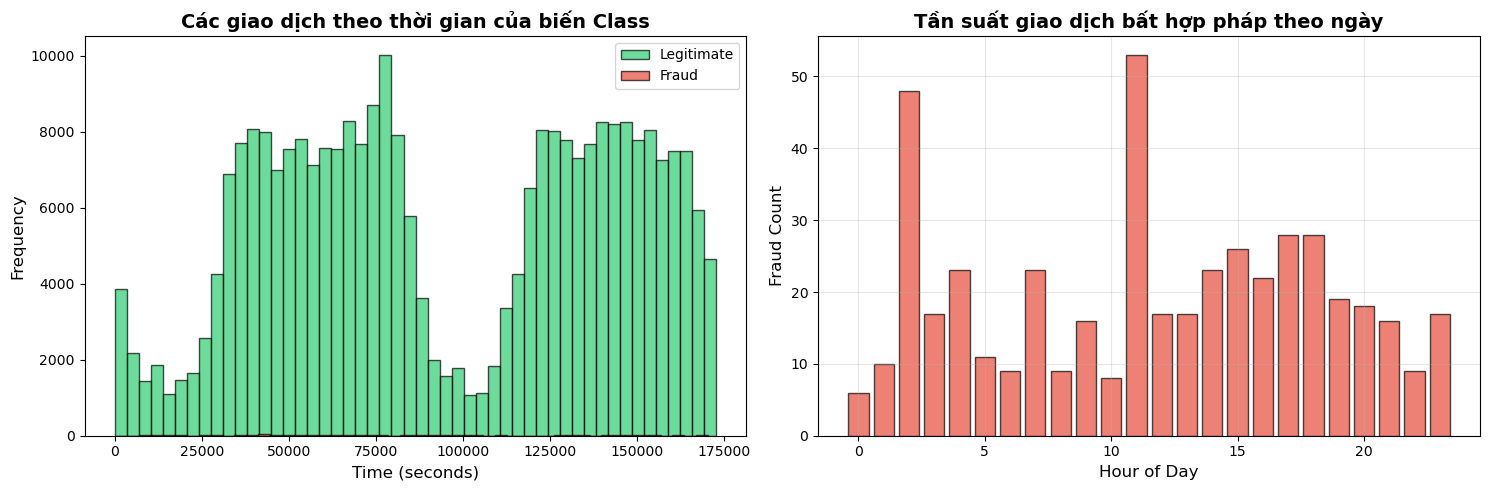

Giao dịch bất hợp pháp vẫn diễn ra ra trong ngày nhưng với số lượng ít


In [39]:
# Phân tích giao dịch hợp pháp theo thời gian
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Class theo thời gian
axes[0].hist(df[df['Class'] == 0]['Time'], bins=50, alpha=0.7, label='Legitimate', color='#2ecc71', edgecolor='black')
axes[0].hist(df[df['Class'] == 1]['Time'], bins=50, alpha=0.7, label='Fraud', color='#e74c3c', edgecolor='black')
axes[0].set_title('Các giao dịch theo thời gian của biến Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (seconds)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()

# Giao dịch bất hợp pháp trong 2 ngày
df['Hour'] = (df['Time'] % 86400) / 3600  # Convert to hour of day
fraud_by_hour = df[df['Class'] == 1].groupby(df['Hour'].astype(int)).size()
axes[1].bar(fraud_by_hour.index, fraud_by_hour.values, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_title('Tần suất giao dịch bất hợp pháp theo ngày', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day', fontsize=12)
axes[1].set_ylabel('Fraud Count', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Clean up temporary column immediately
df.drop('Hour', axis=1, inplace=True)

print("Giao dịch bất hợp pháp vẫn diễn ra ra trong ngày nhưng với số lượng ít")

In [ ]:
# Tiếp theo ta sẽ kiểm tra khả năng diễn ra giao dịch bất hợp pháp từ v1 đến v28


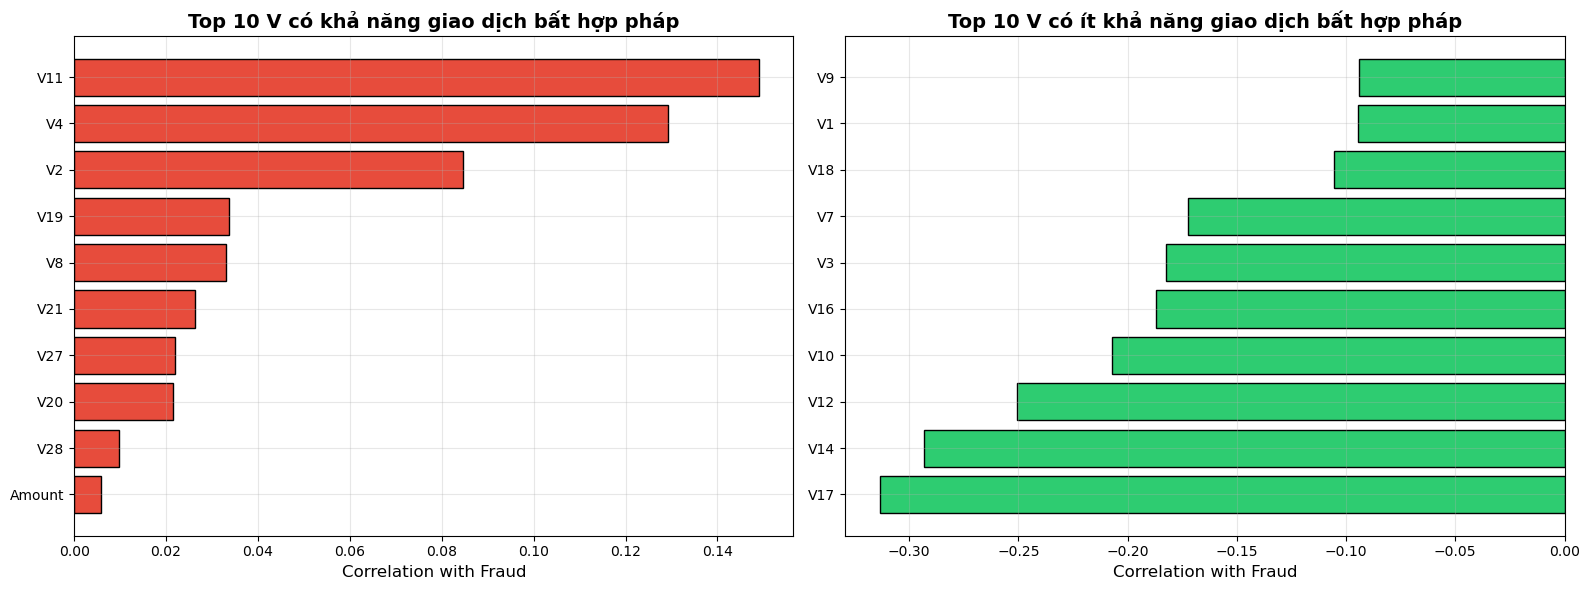


 2 Biểu đồ biểu thị khả năng giao dịch bất hợp pháp cao nhất và thấp nhất
   Gian lận cao nhất: 0.149 (V11)
   Gian lận thấp nhất: -0.313 (V17)


In [42]:
# kiểm tra sự tương quan của biến class
correlations = df.corr()['Class'].drop('Class').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 V có khả năng gian lận cao nhất
top_positive = correlations.head(10)
axes[0].barh(range(len(top_positive)), top_positive.values, color='#e74c3c', edgecolor='black')
axes[0].set_yticks(range(len(top_positive)))
axes[0].set_yticklabels(top_positive.index)
axes[0].set_xlabel('Correlation with Fraud', fontsize=12)
axes[0].set_title('Top 10 V có khả năng giao dịch bất hợp pháp', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3)

# Top 10 V có khả năng gian lận thấp nhất
top_negative = correlations.tail(10)
axes[1].barh(range(len(top_negative)), top_negative.values, color='#2ecc71', edgecolor='black')
axes[1].set_yticks(range(len(top_negative)))
axes[1].set_yticklabels(top_negative.index)
axes[1].set_xlabel('Correlation with Fraud', fontsize=12)
axes[1].set_title('Top 10 V có ít khả năng giao dịch bất hợp pháp', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n 2 Biểu đồ biểu thị khả năng giao dịch bất hợp pháp cao nhất và thấp nhất")
print(f"   Gian lận cao nhất: {correlations.iloc[0]:.3f} ({correlations.index[0]})")
print(f"   Gian lận thấp nhất: {correlations.iloc[-1]:.3f} ({correlations.index[-1]})")

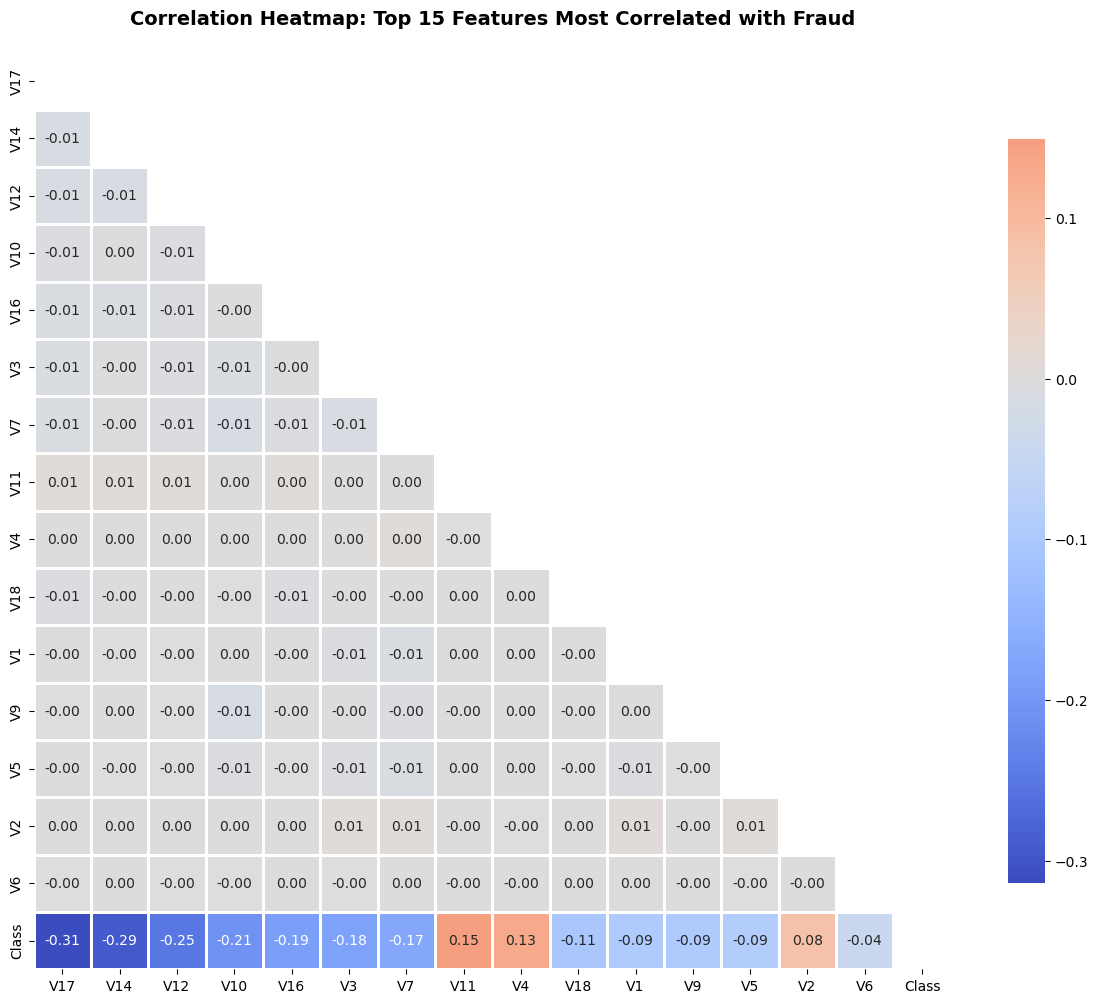


 Ưu điểm nổi bật của PCA trong dataset này:

 Nhờ phép biến đổi PCA, các thành phần chính (V1–V28) là vuông góc với nhau → đa cộng tuyến gần như bằng 0 → cực kỳ lý tưởng cho hầu hết các mô hình machine learning (đặc biệt là hồi quy logistic, SVM, neural network...).


In [47]:
# Correlation heatmap (selected features)
# Select most correlated features with fraud
top_features = correlations.abs().sort_values(ascending=False).head(15).index.tolist()
top_features.append('Class')

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df[top_features].corr(), dtype=bool))
sns.heatmap(df[top_features].corr(), mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Top 15 Features Most Correlated with Fraud', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n Ưu điểm nổi bật của PCA trong dataset này:") 
print("\n Nhờ phép biến đổi PCA, các thành phần chính (V1–V28) là vuông góc với nhau → đa cộng tuyến gần như bằng 0 → cực kỳ lý tưởng cho hầu hết các mô hình machine learning (đặc biệt là hồi quy logistic, SVM, neural network...).")